# QUEST 8
__Seaborn__

In [19]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
database_path = "../data/checking-logs.sqlite"

In [21]:
try:
    connection = sqlite3.connect(database=database_path)
except Exception:
    print("The connection is failed :(")

In [22]:
query = """
select timestamp, numTrials, uid from checker
where status = 'ready' and uid like 'user_%' and labname = 'project1'
"""
df = pd.io.sql.read_sql(query, connection, parse_dates="timestamp")
#df["timestamp"] = df["timestamp"].dt.date

In [23]:
display(df[df["uid"] == "user_18"])

,timestamp,numTrials,uid
296,2020-05-11 10:10:04.166881,1,user_18
301,2020-05-11 14:04:14.877082,2,user_18
302,2020-05-11 14:08:08.392793,3,user_18
303,2020-05-11 14:12:25.322995,4,user_18
304,2020-05-11 14:17:42.247751,5,user_18
306,2020-05-11 14:22:00.520715,6,user_18
307,2020-05-11 14:29:06.844613,7,user_18
595,2020-05-13 18:34:05.505358,8,user_18
771,2020-05-14 16:21:51.341064,9,user_18
781,2020-05-14 16:32:46.077732,10,user_18


Text(0.5, 0.98, 'Dynamic of commits per user in project1')

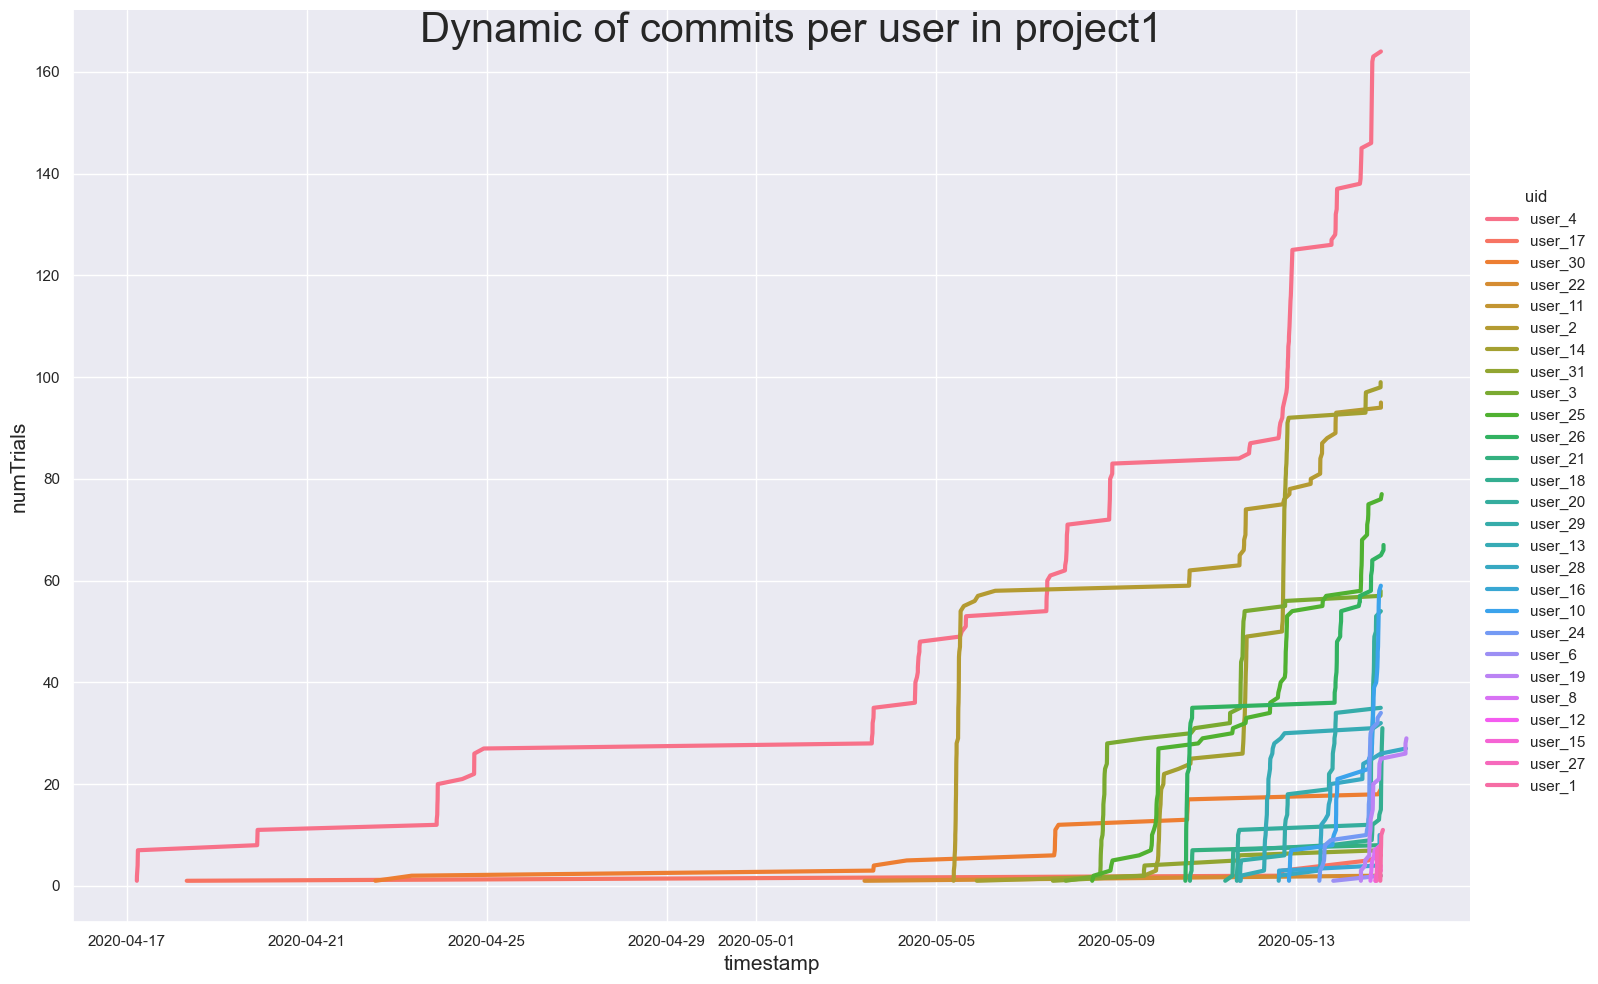

In [24]:
sns.set_theme(palette="dark", rc={'axes.labelsize': 15,'lines.linewidth': 3})
sns.relplot(data=df, kind="line", x="timestamp", y="numTrials", height=10, aspect=1.5, legend="full", hue="uid")
plt.suptitle("Dynamic of commits per user in project1", fontsize=30)

## Questions

### Which user was the leader in the number of commits almost all of the time? - __user_4__

### Which user was the leader for only a short period of time? - __user_2__

In [25]:
connection.close()